# SWOT Pass 91: step-by-step SSHA and nadir verification

This notebook recreates the pass 91 visualization directly from the SWOT L3 LR SSH **Expert** NetCDF.

The workflow is separated into small steps so each part can be inspected before converting it into a reusable Python script.

1. Define the file and map bounds.
2. Inspect the NetCDF variables.
3. Decode scale factors and fill values.
4. Convert longitudes to `-180° to 180°`.
5. Apply the L3 quality mask.
6. Clip to Jacob's Gulf Stream bounding box.
7. Extract mapped nadir locations using `i_num_line` and `i_num_pixel`.
8. Plot the native 2-D SWOT cells and the nadir track.
9. Save the result.

The notebook does **not** calculate a new nadir orbit. The nadir measurements are already blended into the L3 grid; the two index arrays only identify their mapped cells.

## 1. Imports and paths

The NetCDF and notebook can sit in the same folder. `xarray` opens the NetCDF and automatically applies its scale factors, offsets, and missing-value mask.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta

import xarray as xr  # open and work with labeled NetCDF variables
import numpy as np  # array operations, masks, indexing, unit conversions
import matplotlib.pyplot as plt  # Python plotting interface
from matplotlib.ticker import FixedLocator, FuncFormatter  # tick locations and labels
import geopandas as gpd  # read and draw coastline geometry
import cartopy.crs as ccrs              # map projection tools
import cartopy.feature as cfeature      # built-in coastlines and map features
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter  # format longitude and latitude tick labels

DATA_DIR = Path.cwd()

SWOT_FILE = "SWOT_L3_LR_SSH_Expert_014_091_20240420T163005_20240420T172131_v3.0.nc"
FIGURE_NAME = "pass_91_notebook_figure.png"

NC_PATH = DATA_DIR / SWOT_FILE
OUTPUT_PATH = DATA_DIR / FIGURE_NAME

print("NetCDF:", NC_PATH)
print("Exists:", NC_PATH.exists())

NetCDF: /home/ctnguyen/Documents/MOSAICS-2026/SWOT-Web/notebooks/SWOT_L3_LR_SSH_Expert_014_091_20240420T163005_20240420T172131_v3.0.nc
Exists: True


## 2. Geographic bounds

Current Whole Gulf Stream Area of Interest is `(-82, -69, 23, 42)`. The displayed extent is narrower to match the reference image or a smaller bounding box of the person's choice

In [2]:
GULF_BBOX = (-82.0, -69.0, 23.0, 42.0)
VIEW_BBOX = (-82.0, -77.0, 27.0, 34.0)
west, east, south, north = VIEW_BBOX
print("GulfStream bbox:", GULF_BBOX)
print("Displayed bbox:", VIEW_BBOX)

GulfStream bbox: (-82.0, -69.0, 23.0, 42.0)
Displayed bbox: (-82.0, -77.0, 27.0, 34.0)


## 3. Inspect the NetCDF

Important variables:

- `longitude`, `latitude`: position of every cell
- `ssha_unfiltered`: SSHA in the shared KaRIn+nadir image
- `quality_flag`: quality category for each cell
- `cross_track_distance`: distance of each column from nadir
- `i_num_line`, `i_num_pixel`: mapped locations of nadir observations
- `time`: observation time along track

In [3]:
# Open the NetCDF.
# mask_and_scale=True applies scale_factor, add_offset, and fill values.
# decode_times=False keeps time numeric so the later timestamp code stays simple.
ds = xr.open_dataset(
    NC_PATH,
    mask_and_scale=True,
    decode_times=False,
)

# Show the labeled dataset summary.
display(ds)

# Print all variables in rows of five.
all_variables = list(ds.variables)

print(f"All variables ({len(all_variables)} total):")
for start in range(0, len(all_variables), 5):
    print(" | ".join(all_variables[start:start + 5]))

# Print the most important variables with shape, dtype, and units.
print("\nImportant variables:")
for name in [
    "longitude",
    "latitude",
    "ssha_unfiltered",
    "quality_flag",
    "cross_track_distance",
    "i_num_line",
    "i_num_pixel",
    "time",
]:
    variable = ds[name]
    units = variable.attrs.get("units", "")
    print(
        f"{name:22s} "
        f"shape={str(variable.shape):14s} "
        f"dtype={str(variable.dtype):10s} "
        f"units={units}"
    )

<xarray.Dataset> Size: 99MB
Dimensions:               (num_lines: 9860, num_pixels: 69, num_nadir: 1557)
Coordinates:
    latitude              (num_lines, num_pixels) float64 5MB ...
    longitude             (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_nadir
Data variables: (12/21)
    time                  (num_lines) float64 79kB ...
    calibration           (num_lines, num_pixels) float64 5MB ...
    cross_track_distance  (num_pixels) float64 552B ...
    dac                   (num_lines, num_pixels) float64 5MB ...
    internal_tide         (num_lines, num_pixels) float64 5MB ...
    mdt                   (num_lines, num_pixels) float64 5MB ...
    ...                    ...
    ugosa_unfiltered      (num_lines, num_pixels) float64 5MB ...
    vgos_filtered         (num_lines, num_pixels) float64 5MB ...
    vgosa_filtered        (num_lines, num_pixels) float64 5MB ...
    vgosa_unfiltered      (num_lines, num_pixels) float64 5MB ...
    i_num_line            (num_nadir) int16 3kB ...
    i_num_pixel           (num_nadir) int8 2kB ...
Attributes: (12/43)
    Conventions:                     CF-1.9
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0/PIC2/PID0...
    doi:                             https://doi.org/10.24400/527896/A01-2023...
    ...                              ...
    geospatial_lon_max:              358.488666
    date_modified:                   2025-11-24T16:07:14Z
    history:                         2025-11-24T16:07:14Z: Created by DUACS K...
    date_created:                    2025-11-24T16:07:14Z
    date_issued:                     2025-11-24T16:07:14Z
    temporality:                     reproc

All variables (23 total):
time | calibration | cross_track_distance | dac | internal_tide
mdt | mss | ocean_tide | quality_flag | sigma0
ssha_filtered | ssha_unedited | ssha_unfiltered | ugos_filtered | ugosa_filtered
ugosa_unfiltered | vgos_filtered | vgosa_filtered | vgosa_unfiltered | i_num_line
i_num_pixel | latitude | longitude

Important variables:
longitude              shape=(9860, 69)     dtype=float64    units=degrees_east
latitude               shape=(9860, 69)     dtype=float64    units=degrees_north
ssha_unfiltered        shape=(9860, 69)     dtype=float64    units=m
quality_flag           shape=(9860, 69)     dtype=uint8      units=1
cross_track_distance   shape=(69,)          dtype=float64    units=km
i_num_line             shape=(1557,)        dtype=int16      units=count
i_num_pixel            shape=(1557,)        dtype=int8       units=count
time                   shape=(9860,)        dtype=float64    units=seconds since 2000-01-01 00:00:00.0


## 4. Automatic NetCDF decoding

`xarray` automatically applies each variable's `scale_factor`, `add_offset`, and `_FillValue`, so the manual `read_scaled()` function is no longer needed.

In [4]:
# Confirm that xarray decoded the main scientific variable.
print(ds["ssha_unfiltered"])

<xarray.DataArray 'ssha_unfiltered' (num_lines: 9860, num_pixels: 69)> Size: 5MB
[680340 values with dtype=float64]
Coordinates:
    latitude   (num_lines, num_pixels) float64 5MB ...
    longitude  (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels
Attributes:
    comment:              Height of the sea surface anomaly with all correcti...
    long_name:            sea surface height anomaly calibrated and edited
    standard_name:        sea_surface_height_above_mean_sea_level
    units:                m
    ancillary_variables:  quality_flag


## 5. Load the SWOT arrays

SSHA is converted from meters to centimeters. Longitudes above 180° are converted to the usual western-negative convention.

In [5]:
longitude = ds["longitude"].values
latitude = ds["latitude"].values
ssha_m = ds["ssha_unfiltered"].values
quality_flag = ds["quality_flag"].values
cross_track_distance = ds["cross_track_distance"].values
i_num_line = ds["i_num_line"].values.astype(int)
i_num_pixel = ds["i_num_pixel"].values.astype(int)
time_seconds = ds["time"].values.astype(float)

# Convert 0–360° longitude into the -180–180° convention.
longitude = np.where(longitude > 180.0, longitude - 360.0, longitude)

# Convert SSHA from meters to centimeters.
ssha_cm = ssha_m * 100.0

print("2-D grid:", ssha_cm.shape)
print("Nadir observations:", len(i_num_line))

center_column = np.argmin(np.abs(cross_track_distance))
distance_units = ds["cross_track_distance"].attrs.get("units", "")

print("Center column:", center_column)
print(
    "Center distance:",
    cross_track_distance[center_column],
    distance_units,
)

2-D grid: (9860, 69)
Nadir observations: 1557
Center column: 34
Center distance: 0.0 km


## 6. Apply quality control

This notebook retains quality values `0` and `3`, then masks all other cells. No values are interpolated or replaced.

In [6]:
good_quality = np.isin(quality_flag, [0, 3])
valid = good_quality & np.isfinite(longitude) & np.isfinite(latitude) & np.isfinite(ssha_cm)
ssha_qc_cm = np.where(valid, ssha_cm, np.nan)
print("Valid cells after QC:", np.count_nonzero(np.isfinite(ssha_qc_cm)))

Valid cells after QC: 304183


## 7. Clip to Jacob's AOI

The original 2-D swath geometry is preserved. A mask only removes cells outside the full AOI.

In [7]:
gw, ge, gs, gn = GULF_BBOX

inside_gulf = (
    (longitude >= gw)
    & (longitude <= ge)
    & (latitude >= gs)
    & (latitude <= gn)
)

ssha_gulf_cm = np.where(inside_gulf, ssha_qc_cm, np.nan)

rows_with_data = np.where(
    np.any(np.isfinite(ssha_gulf_cm), axis=1)
)[0]

print("Rows intersecting Gulf Stream bbox:", len(rows_with_data))

Rows intersecting Gulf Stream bbox: 545


## 8. Extract mapped nadir locations

The nadir data already exists in the blended L3 field. These two arrays tell us which 2-D cells correspond to the nadir observations.

In [8]:
index_ok = ((i_num_line >= 0) & (i_num_line < longitude.shape[0]) &
            (i_num_pixel >= 0) & (i_num_pixel < longitude.shape[1]))

nadir_rows = i_num_line[index_ok]
nadir_cols = i_num_pixel[index_ok]
nadir_lon = longitude[nadir_rows, nadir_cols]
nadir_lat = latitude[nadir_rows, nadir_cols]
nadir_ssha_cm = ssha_cm[nadir_rows, nadir_cols]

nadir_in_view = (np.isfinite(nadir_lon) & np.isfinite(nadir_lat) &
                 (nadir_lon >= west) & (nadir_lon <= east) &
                 (nadir_lat >= south) & (nadir_lat <= north))

print("Nadir observations in view:", np.count_nonzero(nadir_in_view))
print("Mapped pixel columns:", np.unique(nadir_cols))

Nadir observations in view: 90
Mapped pixel columns: [34]


## 9. Representative timestamp

The title uses the median along-track row inside the displayed map extent.

In [9]:
view_cells = ((longitude >= west) & (longitude <= east) &
              (latitude >= south) & (latitude <= north))
view_rows = np.where(np.any(view_cells, axis=1))[0]
median_row = int(np.median(view_rows))
plot_time = datetime(2000, 1, 1) + timedelta(seconds=float(time_seconds[median_row]))
print(plot_time.strftime("%Y-%m-%d %H:%M:%S UTC"))

2024-04-20 17:04:44 UTC


## 10. Plot the native swath

`pcolormesh` draws the native geolocated cells. Matplotlib's own spines and outward ticks form the corner cross. Endpoint labels are avoided by starting ticks at 28°N and 81°W rather than placing both labels directly at the lower-left corner.

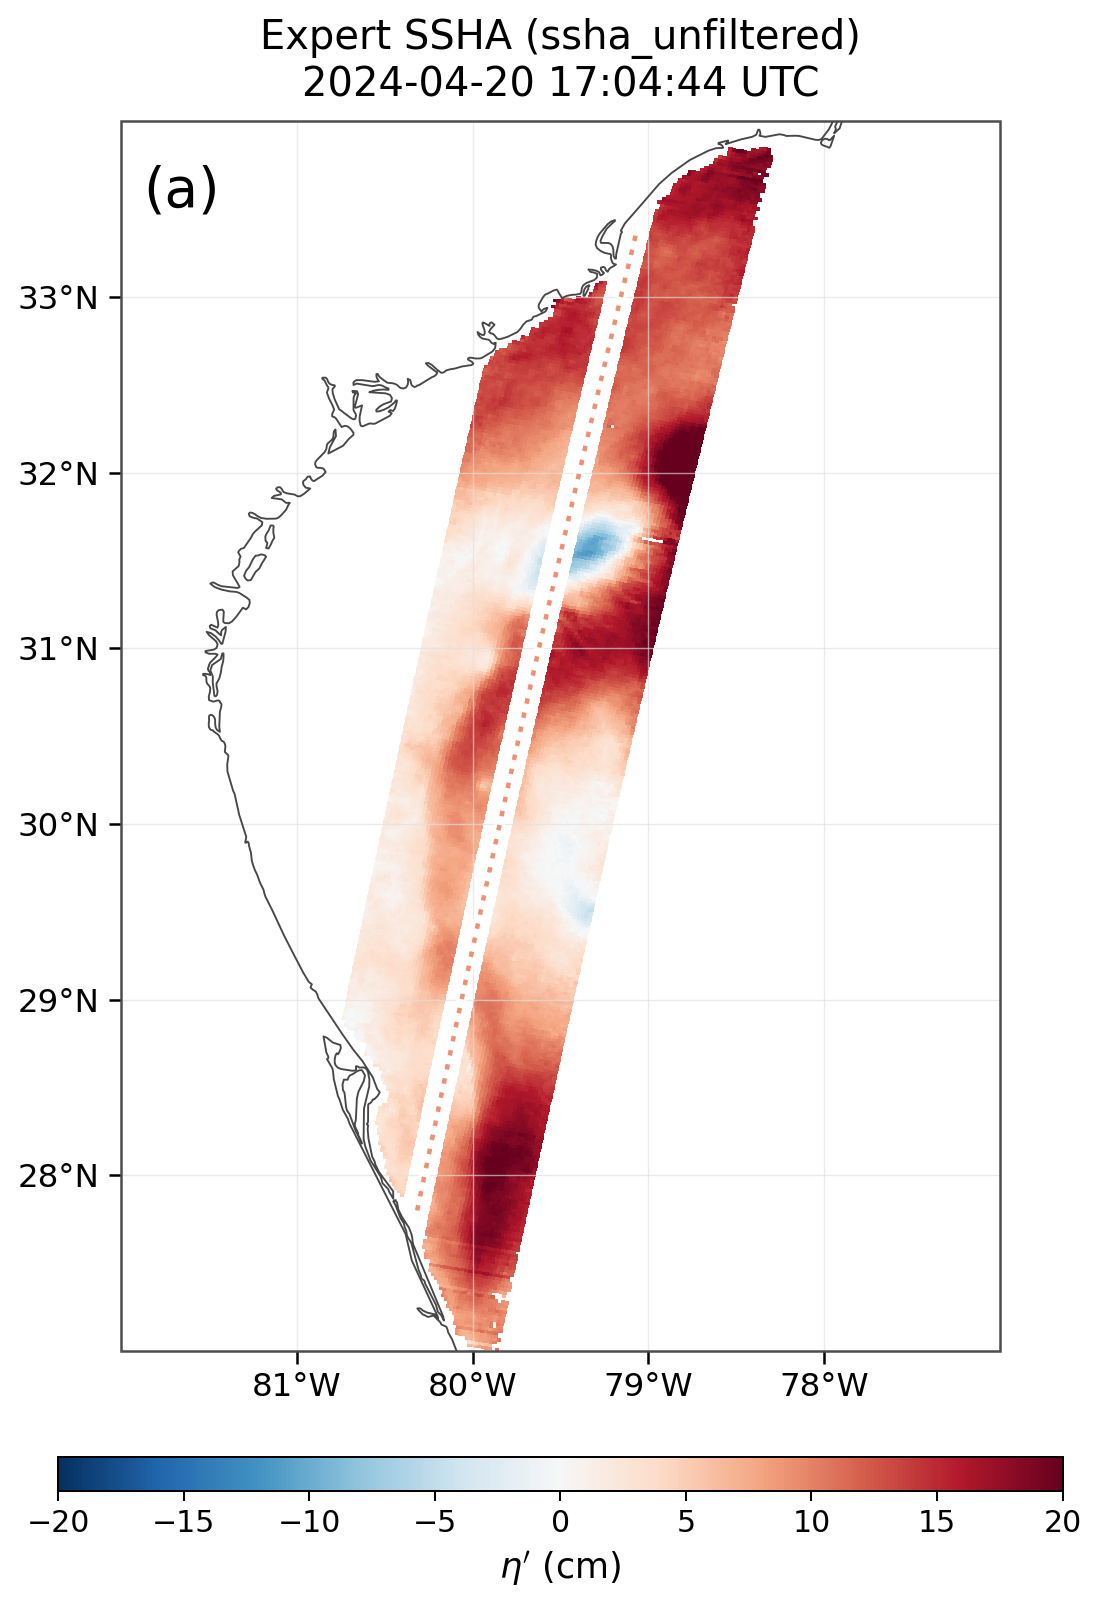

Saved: /home/ctnguyen/Documents/MOSAICS-2026/SWOT-Web/notebooks/pass_91_notebook_figure.png


In [10]:
# Create a figure and map axis using a simple latitude/longitude projection.
fig, ax = plt.subplots(
    figsize=(7.2, 10.2),
    dpi=180,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Plot the SWOT swath using the native longitude/latitude cell positions.
# transform=ccrs.PlateCarree() tells Cartopy that the data are already in
# regular geographic coordinates (lon/lat).
mesh = ax.pcolormesh(
    longitude,
    latitude,
    ssha_gulf_cm,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
    shading="auto",
    rasterized=True,
    zorder=1,
)

# Add coastline outlines from Cartopy's built-in Natural Earth features.
# This replaces the shapefile + GeoPandas approach.
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.75,
    edgecolor="0.28",
    zorder=3,
)

# Plot a thick white line first so the nadir path stands out clearly.
ax.plot(
    nadir_lon[nadir_in_view],
    nadir_lat[nadir_in_view],
    transform=ccrs.PlateCarree(),
    color="white",
    linewidth=4.2,
    alpha=0.95,
    zorder=4,
)

# Plot the dotted colored nadir track on top of the white line.
ax.plot(
    nadir_lon[nadir_in_view],
    nadir_lat[nadir_in_view],
    transform=ccrs.PlateCarree(),
    color="#ef8f73",
    linewidth=1.8,
    linestyle=(0, (1.2, 2.0)),
    zorder=5,
)

# Set the geographic extent of the map:
# [west, east, south, north]
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())

# Set the longitude and latitude tick locations.
ax.set_xticks(np.arange(-81, -77, 1), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(28, 34, 1), crs=ccrs.PlateCarree())

# Format the tick labels as geographic coordinates.
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

# Add light grid lines behind the data.
ax.gridlines(
    draw_labels=False,
    linewidth=0.55,
    color="0.88",
    alpha=0.65,
    linestyle="-",
    zorder=0,
)

# Style the tick marks and labels.
ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.0,
    labelsize=13,
    top=False,
    right=False,
)

# Style the plot border.
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("0.30")

# Add the two-line figure title.
ax.set_title(
    "Expert SSHA (ssha_unfiltered)\n"
    + plot_time.strftime("%Y-%m-%d %H:%M:%S UTC"),
    fontsize=16,
    pad=10,
)

# Add the panel label "(a)" in the upper-left corner.
ax.text(
    0.025,
    0.965,
    "(a)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=22,
)

# Add a horizontal colorbar for SSHA.
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.075,
    fraction=0.055,
    aspect=30,
)

# Label the colorbar in centimeters.
cbar.set_label(r"$\eta'$ (cm)", fontsize=14)

# Put ticks every 5 cm from -20 to 20.
cbar.set_ticks(np.arange(-20, 21, 5))

# Style the colorbar tick labels.
cbar.ax.tick_params(labelsize=12, direction="out", length=4)

# Save the finished figure to disk.
fig.savefig(
    OUTPUT_PATH,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

# Show the plot in the notebook.
plt.show()

# Print where the figure was saved.
print("Saved:", OUTPUT_PATH.resolve())

Section 11. Plot Whole Native Swoth

Longitude shape: (9860, 69)
Latitude shape: (9860, 69)
SSHA shape: (9860, 69)
Valid SSHA cells: 304183
Valid mapped nadir observations: 1557


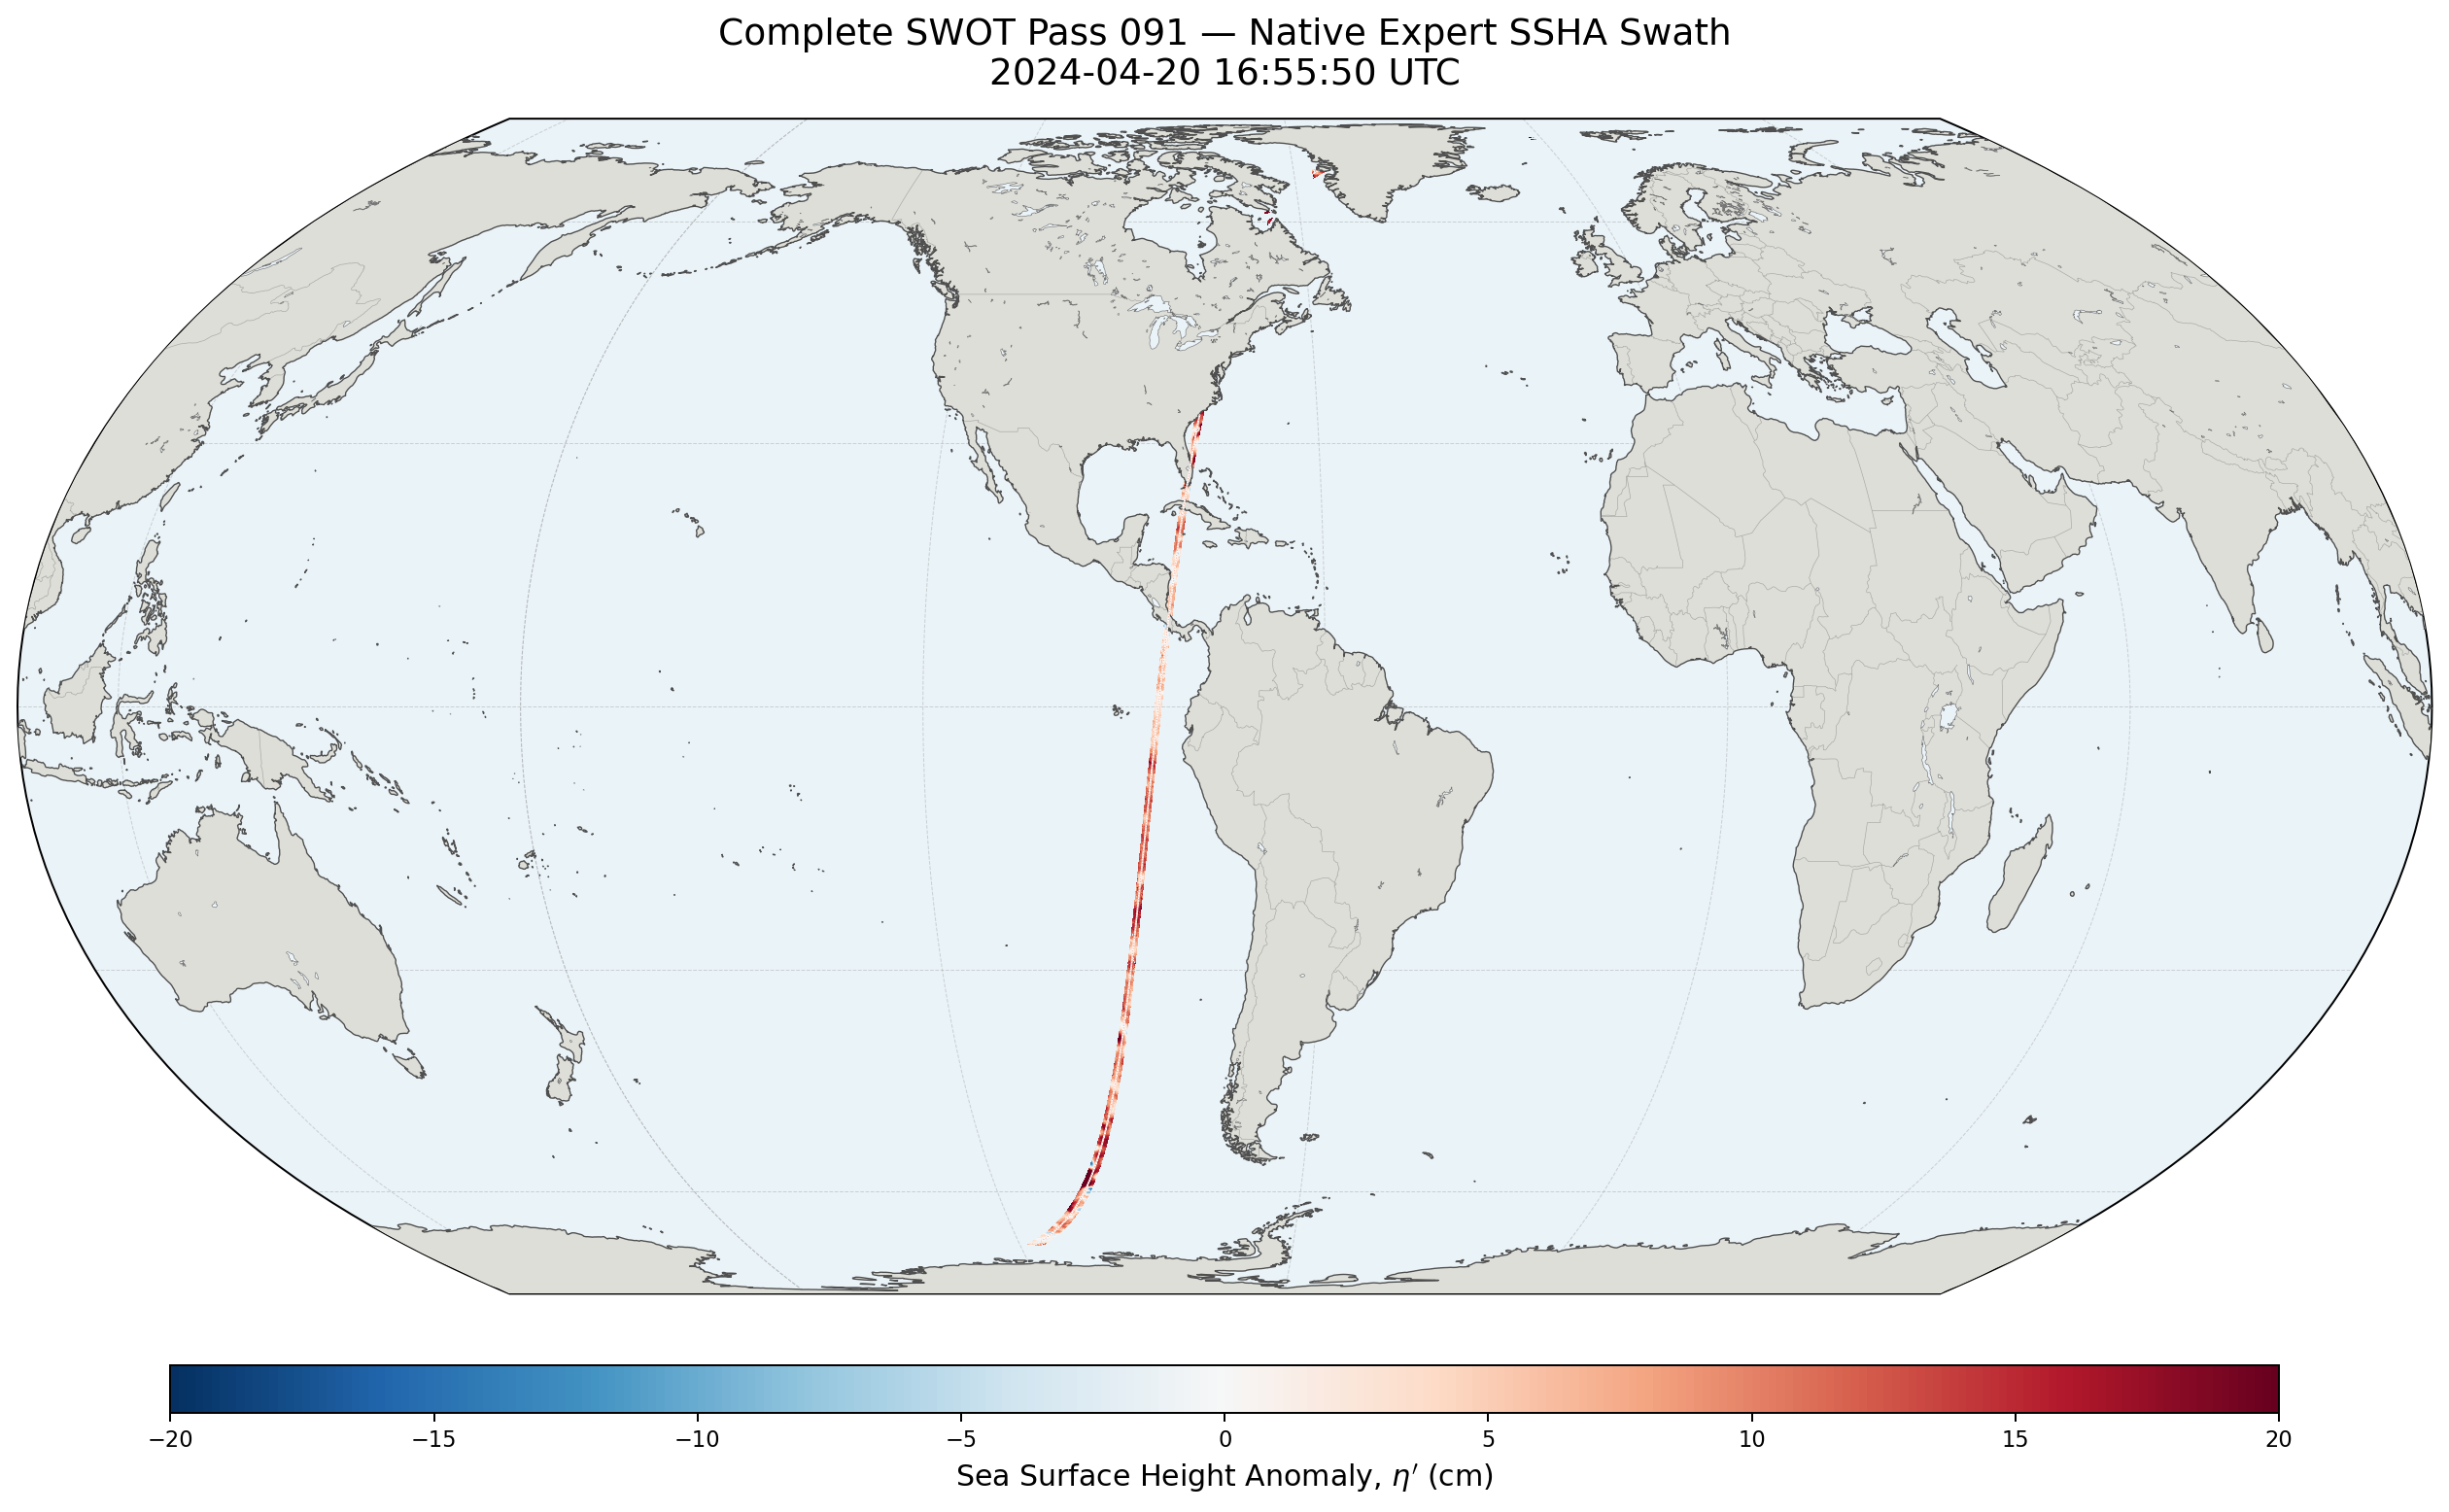

Saved: /home/ctnguyen/Documents/MOSAICS-2026/SWOT-Web/notebooks/pass_91_complete_global_native_swath.png


In [11]:
# ============================================================
# 11. Plot the complete native SWOT pass on a global map
# ============================================================

# This section displays every native SWOT cell contained in the
# current NetCDF file.
#
# No geographic bounding box is applied.
# No along-track rows are removed.
# No interpolation or regular-grid resampling is performed.
#
# Important:
# One SWOT pass file normally contains one half-orbit, not every
# SWOT observation around the world.


# ------------------------------------------------------------
# 1. Use the complete native SWOT arrays
# ------------------------------------------------------------

longitude_global = longitude
latitude_global = latitude

# Use the quality-controlled SSHA array.
# Invalid or rejected measurements remain NaN.
ssha_global_cm = ssha_qc_cm


# ------------------------------------------------------------
# 2. Print basic information about the full pass
# ------------------------------------------------------------

print("Longitude shape:", longitude_global.shape)
print("Latitude shape:", latitude_global.shape)
print("SSHA shape:", ssha_global_cm.shape)

print(
    "Valid SSHA cells:",
    np.count_nonzero(np.isfinite(ssha_global_cm))
)


# ------------------------------------------------------------
# 3. Prepare the complete mapped nadir track
# ------------------------------------------------------------
#
# nadir_lon, nadir_lat, and nadir_ssha_cm were created earlier
# from the mapped nadir indices i_num_line and i_num_pixel.
#
# Only nadir observations with valid mapped SSHA values are used.

nadir_global_valid = (
    np.isfinite(nadir_lon)
    & np.isfinite(nadir_lat)
    & np.isfinite(nadir_ssha_cm)
)

# Copy the arrays so invalid points can be replaced by NaN.
#
# NaN values break the line. This prevents Matplotlib from
# connecting separate valid sections across invalid regions.
nadir_plot_lon = nadir_lon.astype(float).copy()
nadir_plot_lat = nadir_lat.astype(float).copy()

nadir_plot_lon[~nadir_global_valid] = np.nan
nadir_plot_lat[~nadir_global_valid] = np.nan

print(
    "Valid mapped nadir observations:",
    np.count_nonzero(nadir_global_valid)
)


# ------------------------------------------------------------
# 4. Create a global Cartopy map
# ------------------------------------------------------------
#
# EqualEarth provides a clean global view.
#
# central_longitude=-75 centers the map closer to the Atlantic
# and the path of Pass 091.

fig, ax = plt.subplots(
    figsize=(15, 8.5),
    dpi=180,
    subplot_kw={
        "projection": ccrs.EqualEarth(
            central_longitude=-75
        )
    },
)

# Give the ocean a light-blue background.
ax.set_facecolor("#eaf3f8")


# ------------------------------------------------------------
# 5. Plot every native SWOT cell in the file
# ------------------------------------------------------------
#
# pcolormesh uses the original two-dimensional longitude and
# latitude arrays.
#
# The swath is not interpolated onto a new raster.

mesh = ax.pcolormesh(
    longitude_global,
    latitude_global,
    ssha_global_cm,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
    shading="auto",
    rasterized=True,
    zorder=2,
)


# ------------------------------------------------------------
# 6. Show the complete world
# ------------------------------------------------------------

ax.set_global()


# ------------------------------------------------------------
# 7. Add a cleaner global basemap
# ------------------------------------------------------------

# Land polygons.
ax.add_feature(
    cfeature.LAND.with_scale("50m"),
    facecolor="#deded8",
    edgecolor="none",
    zorder=3,
)

# Coastlines.
ax.add_feature(
    cfeature.COASTLINE.with_scale("50m"),
    edgecolor="#4f4f4f",
    linewidth=0.55,
    zorder=4,
)

# Country borders.
ax.add_feature(
    cfeature.BORDERS.with_scale("50m"),
    edgecolor="#888888",
    linewidth=0.25,
    alpha=0.65,
    zorder=4,
)

# Lakes.
ax.add_feature(
    cfeature.LAKES.with_scale("50m"),
    facecolor="#eaf3f8",
    edgecolor="#777777",
    linewidth=0.25,
    zorder=4,
)


# ------------------------------------------------------------
# 8. Add global latitude/longitude gridlines
# ------------------------------------------------------------

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.4,
    color="#8f8f8f",
    alpha=0.35,
    linestyle="--",
    zorder=1,
)


# ------------------------------------------------------------
# 9. Plot the valid mapped nadir track
# ------------------------------------------------------------
#
# The line is kept very thin because a thick dashed line looks
# like large boxes on a whole-world map.

# Thin white outline.
ax.plot(
    nadir_plot_lon,
    nadir_plot_lat,
    transform=ccrs.PlateCarree(),
    color="white",
    linewidth=0.7,
    solid_capstyle="round",
    zorder=5,
)

# Thin dotted salmon-colored nadir line.
ax.plot(
    nadir_plot_lon,
    nadir_plot_lat,
    transform=ccrs.PlateCarree(),
    color="#ef8f73",
    linewidth=0.28,
    linestyle=(0, (1.0, 2.8)),
    dash_capstyle="round",
    zorder=6,
)


# ------------------------------------------------------------
# 10. Determine a representative time for the pass
# ------------------------------------------------------------

valid_time = np.isfinite(time_seconds)

if np.any(valid_time):

    valid_time_values = time_seconds[valid_time]

    middle_time_index = len(valid_time_values) // 2

    plot_time = (
        datetime(2000, 1, 1)
        + timedelta(
            seconds=float(
                valid_time_values[middle_time_index]
            )
        )
    )

    time_title = plot_time.strftime(
        "%Y-%m-%d %H:%M:%S UTC"
    )

else:

    time_title = "Time unavailable"


# ------------------------------------------------------------
# 11. Add the title
# ------------------------------------------------------------

ax.set_title(
    "Complete SWOT Pass 091 — Native Expert SSHA Swath\n"
    + time_title,
    fontsize=15,
    pad=14,
)


# ------------------------------------------------------------
# 12. Add the SSHA colorbar
# ------------------------------------------------------------

colorbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.055,
    fraction=0.045,
    aspect=45,
    shrink=0.82,
)

colorbar.set_label(
    r"Sea Surface Height Anomaly, $\eta'$ (cm)",
    fontsize=12,
)

colorbar.set_ticks(
    np.arange(-20, 21, 5)
)

colorbar.ax.tick_params(
    labelsize=9
)


# ------------------------------------------------------------
# 13. Improve the figure spacing
# ------------------------------------------------------------

fig.tight_layout()


# ------------------------------------------------------------
# 14. Save the complete global-pass figure
# ------------------------------------------------------------

GLOBAL_SWATH_OUTPUT_PATH = (
    DATA_DIR
    / "pass_91_complete_global_native_swath.png"
)

fig.savefig(
    GLOBAL_SWATH_OUTPUT_PATH,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 15. Display the figure
# ------------------------------------------------------------

plt.show()

print(
    "Saved:",
    GLOBAL_SWATH_OUTPUT_PATH.resolve()
)

## 11. Convert the verified workflow into a script

After the notebook result matches the reference, move the stable parts into functions such as:

- `read_scaled()`
- `load_swot_pass()`
- `apply_quality_mask()`
- `extract_nadir_track()`
- `plot_swot_pass()`

The notebook remains the analysis record; the script becomes the repeatable pass-processing tool.